In [5]:
# ✅ Kaggle Setup
# Dataset should be added via: Add Data → Your Dataset (dreamdiffusion-bcs)
# Input files are at: /kaggle/input/dreamdiffusion-bcs/
# Output files go to: /kaggle/working/

import os
print("Input files:", os.listdir("/kaggle/input/datasets/vaibhavkalyan/dreamdiffusion-bcs"))
print("GPU available:", __import__("torch").cuda.is_available())

Input files: ['eeg_to_clip_projector_best (1).pth', 'imageNet_images', 'clip_image_embeddings.pt', 'eeg_5_95_std.pth', 'latest.pth']
GPU available: True


In [6]:
# ✅ ImageNet images already uploaded as folder — no unzip needed
import os

image_path_root = "/kaggle/input/datasets/vaibhavkalyan/dreamdiffusion-bcs/imageNet_images"

# Verify it's accessible
classes = os.listdir(image_path_root)
print(f"✅ Found {len(classes)} ImageNet class folders")
print("Sample folders:", classes[:5])

✅ Found 1 ImageNet class folders
Sample folders: ['imageNet_images']


In [7]:
import torch.nn as nn
import torch
import pandas as pd
import numpy as np
import torch.nn.functional as F
from torch.utils.data import DataLoader
from transformers import CLIPImageProcessor, CLIPVisionModel
from diffusers import UNet2DConditionModel, AutoencoderKL, DDPMScheduler
from diffusers.models.attention_processor import Attention
import torchvision.transforms as T
import wandb
from PIL import Image
import os
from tqdm import tqdm

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [8]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: cuda


In [9]:
import tensorflow as tf
print(tf.test.gpu_device_name())

2026-07-01 05:44:47.802930: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782884687.974554      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782884688.027636      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782884688.456101      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782884688.456143      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782884688.456146      58 computation_placer.cc:177] computation placer alr

/device:GPU:0


I0000 00:00:1782884697.097271      58 gpu_device.cc:2019] Created device /device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782884697.103177      58 gpu_device.cc:2019] Created device /device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [10]:
class EEGToCLIPProjector(nn.Module):
    def __init__(self, eeg_dim=1024, clip_dim=512):
        super().__init__()
        self.project = nn.Sequential(
            nn.Linear(eeg_dim, 1024),
            nn.LayerNorm(1024),
            nn.GELU(),
            nn.Linear(1024, clip_dim),
        )

    def forward(self, x):
        x = self.project(x)
        return F.normalize(x, dim=-1)

In [11]:
import torch
import pandas as pd
import numpy as np
import torch.nn as nn

def normalize_channels(epoch, means=None, stddevs=None):
    if not isinstance(epoch, torch.Tensor):
        epoch = torch.tensor(epoch.copy(), dtype=torch.float32)
    if means is None or stddevs is None:
        means = epoch.mean(dim=1, keepdim=True)
        stddevs = epoch.std(dim=1, keepdim=True)
    else:
        if isinstance(means, np.ndarray):
            means = torch.tensor(means, dtype=epoch.dtype)
        if isinstance(stddevs, np.ndarray):
            stddevs = torch.tensor(stddevs, dtype=epoch.dtype)
    stddevs = stddevs.clone()
    stddevs[stddevs == 0] = 1e-6
    return (epoch - means) / stddevs

def pad_channels_to_128(epoch):
    num_channels = epoch.shape[0]
    if num_channels == 128:
        return epoch
    elif num_channels < 128:
        reps = 128 // num_channels + 1
        padded = np.tile(epoch, (reps, 1))[:128, :]
        return padded
    else:
        return epoch[:128, :]

def tokenize_sample(eeg_sample, token_length=4):
    C, T = eeg_sample.shape
    pad_length = (token_length - (T % token_length)) % token_length
    if pad_length > 0:
        padded_data = np.pad(eeg_sample, ((0, 0), (0, pad_length)), mode="edge")
    else:
        padded_data = eeg_sample
    num_tokens = padded_data.shape[1] // token_length
    tokens = padded_data.reshape(128, num_tokens, token_length)
    tokens = np.transpose(tokens, (1, 0, 2))
    return tokens

data = torch.load("/kaggle/input/datasets/vaibhavkalyan/dreamdiffusion-bcs/eeg_5_95_std.pth", weights_only=False)

raw_eeg_samples = []
original_image_indices = []

for item in data["dataset"]:
    raw_eeg_samples.append(item["eeg"].detach().cpu().numpy())
    original_image_indices.append(item["image"])

ima_lookup = data["images"]
del data
if torch.cuda.is_available():
    torch.cuda.empty_cache()

processed_eeg_samples = []
for eeg_sample in raw_eeg_samples:
    padded_eeg = pad_channels_to_128(eeg_sample)
    normalized_eeg = normalize_channels(padded_eeg).cpu().numpy()
    tokenized_eeg = tokenize_sample(normalized_eeg)
    processed_eeg_samples.append(tokenized_eeg)

del raw_eeg_samples
if torch.cuda.is_available():
    torch.cuda.empty_cache()

device = "cuda" if torch.cuda.is_available() else "cpu"
projection = nn.Linear(128 * 4, 1024).to(device)

def embed(tokens):
    if isinstance(tokens, np.ndarray):
        tokens_tensor = torch.from_numpy(tokens).to(torch.float32).to(device)
    else:
        tokens_tensor = tokens.clone().detach().to(torch.float32).to(device)
    flattened = tokens_tensor.reshape(-1, 128 * 4)
    embeddings = projection(flattened)
    return embeddings

all_embeddings_avg = []
final_image_names = []

for i, tokenized_eeg_sample in enumerate(processed_eeg_samples):
    eeg_embeddings_on_device = embed(tokenized_eeg_sample)
    avg_embedding = eeg_embeddings_on_device.mean(dim=0).detach().cpu().numpy()
    all_embeddings_avg.append(avg_embedding)
    image_index = original_image_indices[i]
    image_name = ima_lookup[image_index] + ".JPEG"
    final_image_names.append(image_name)

del processed_eeg_samples
del original_image_indices
if torch.cuda.is_available():
    torch.cuda.empty_cache()

pdatac = pd.DataFrame({
    "embeddingsavg": all_embeddings_avg,
    "image": [idx for idx in range(len(all_embeddings_avg))],
    "name": final_image_names
})

pdatac.drop(pdatac[pdatac["name"] == "n03452741_17620.JPEG"].index, inplace=True)
print(f"✅ pdatac ready with {len(pdatac)} samples")

✅ pdatac ready with 11959 samples


In [12]:
pdatac

,embeddingsavg,image,name
0,"[-0.0057535577, 0.041723832, 0.0010242243, 0.0...",0,n02951358_31190.JPEG
1,"[-0.005242247, 0.03882471, -0.002826986, 0.042...",1,n03452741_16744.JPEG
2,"[-0.005339292, 0.04149374, 0.0010587483, 0.040...",2,n04069434_10318.JPEG
3,"[-0.0045620734, 0.041407563, 0.0008136673, 0.0...",3,n02951358_34807.JPEG
4,"[-0.005351966, 0.03935252, -0.002654274, 0.041...",4,n03452741_5499.JPEG
...,...,...,...
11960,"[-0.00502219, 0.037431598, -0.003940589, 0.041...",11960,n02492035_4451.JPEG
11961,"[-0.005843547, 0.038451128, 0.0004140194, 0.04...",11961,n07873807_8902.JPEG
11962,"[-0.0031889433, 0.041697193, -0.00012139196, 0...",11962,n02607072_304.JPEG
11963,"[-0.0034168519, 0.0412337, 0.0010207568, 0.039...",11963,n03297495_2959.JPEG


In [13]:
model = EEGToCLIPProjector().to(device)
model.load_state_dict(torch.load("/kaggle/input/datasets/vaibhavkalyan/dreamdiffusion-bcs/eeg_to_clip_projector_best (1).pth"))
model.eval()

projected_embeddings = []

with torch.no_grad():
    for eeg in pdatac["embeddingsavg"]:
        if eeg is not None:
            eeg = (torch.tensor(eeg)).detach().clone().float().to(device)
            proj = model(eeg.unsqueeze(0))
            projected_embeddings.append(proj.squeeze(0).cpu())
        else:
            projected_embeddings.append(None)

print(f"✅ Computed {len(projected_embeddings)} projected embeddings")

✅ Computed 11959 projected embeddings


In [15]:
class EEGCrossAttentionProcessor:
    def __init__(self):
        self.to_k = None
        self.to_v = None

    def __call__(self, query, encoder_hidden_states, **kwargs):
        if self.to_k is None:
            self.to_k = kwargs["attention"].to_k
            self.to_v = kwargs["attention"].to_v
        key = self.to_k(encoder_hidden_states)
        value = self.to_v(encoder_hidden_states)
        return kwargs["attention"]._attention(query, key, value, **kwargs)

In [13]:
class EEGConditionedUNet(UNet2DConditionModel):
    def set_attention_processor(self):
        for name, module in self.named_modules():
            if isinstance(module, Attention):
                processor = EEGCrossAttentionProcessor()
                module.set_processor(processor)

In [14]:
def load_models():
    vae = AutoencoderKL.from_pretrained("stable-diffusion-v1-5/stable-diffusion-v1-5", subfolder="vae").eval().cuda()
    unet = EEGConditionedUNet.from_pretrained("stable-diffusion-v1-5/stable-diffusion-v1-5", subfolder="unet").cuda()
    scheduler = DDPMScheduler.from_pretrained("stable-diffusion-v1-5/stable-diffusion-v1-5", subfolder="scheduler")

    for param in unet.parameters():
        param.requires_grad = False
    for name, module in unet.named_modules():
        if isinstance(module, Attention):
            module.to_k.weight.requires_grad = True
            module.to_v.weight.requires_grad = True

    print("✅ Models loaded")
    return vae, unet, scheduler

In [15]:
class EEGImageLatentDataset(torch.utils.data.Dataset):
    def __init__(self, eeg_clip_embedding_tensor, image_latents_tensor):
        self.eeg_clip_embeddings = eeg_clip_embedding_tensor
        self.image_latents = image_latents_tensor

    def __len__(self):
        return len(self.eeg_clip_embeddings)

    def __getitem__(self, idx):
        return self.image_latents[idx], self.eeg_clip_embeddings[idx]

In [16]:
class EEGToCLIPText(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(512, 77 * 768)

    def forward(self, x):
        out = self.linear(x)
        return out.view(-1, 77, 768)

eeg_to_clip_text = EEGToCLIPText().cuda()

In [17]:
def train(model_components, dataloader, num_epochs=30, ckpt_dir="/kaggle/working/checkpoints", patience=10):
    print("Training started", flush=True)

    os.makedirs(ckpt_dir, exist_ok=True)
    vae, unet, scheduler = model_components
    optimizer = torch.optim.AdamW(
        list(eeg_to_clip_text.parameters()) + list(filter(lambda p: p.requires_grad, unet.parameters())), lr=1e-5
    )

    scaler = torch.amp.GradScaler("cuda")
    start_epoch = 0
    ckpt_path = os.path.join(ckpt_dir, "latest.pth")
    ckpt_path_input = "/kaggle/input/dreamdiffusion-bcs/latest.pth"
    if os.path.exists(ckpt_path_input):
        checkpoint = torch.load(ckpt_path_input)
        eeg_to_clip_text.load_state_dict(checkpoint["model"])
        unet.load_state_dict(checkpoint["unet"])
        optimizer.load_state_dict(checkpoint["optimizer"])
        start_epoch = checkpoint["epoch"] + 1
        print(f"Resuming training from epoch {start_epoch}", flush=True)

    print("Starting training loop...", flush=True)
    best_loss = float("inf")
    epochs_no_improve = 0
    for epoch in range(start_epoch, num_epochs):
        running_loss = 0.0
        for latents, eeg_clip_embeds in tqdm(dataloader, desc=f"Epoch {epoch}"):
            latents = latents.cuda(non_blocking=True)
            eeg_clip_embeds = eeg_clip_embeds.cuda(non_blocking=True)
            eeg_clip_embeds = eeg_to_clip_text(eeg_clip_embeds)

            bsz = latents.size(0)
            t = torch.randint(0, scheduler.config.num_train_timesteps, (bsz,), device="cuda").long()
            noise = torch.randn_like(latents)
            noisy_latents = scheduler.add_noise(latents, noise, t)

            with torch.amp.autocast("cuda"):
                noise_pred = unet(noisy_latents, t, encoder_hidden_states=eeg_clip_embeds).sample
                loss = F.mse_loss(noise_pred, noise)

            optimizer.zero_grad()
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item()

        avg_loss = running_loss / len(dataloader)
        print(f"Epoch {epoch} Loss: {avg_loss:.4f}", flush=True)

        try:
            torch.save({
                "epoch": epoch,
                "model": eeg_to_clip_text.state_dict(),
                "unet": unet.state_dict(),
                "optimizer": optimizer.state_dict()
            }, ckpt_path)
            print(f"Saved at {ckpt_path}")
        except Exception as e:
            print("Checkpoint save failed:", e)

        if avg_loss < best_loss:
            best_loss = avg_loss
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping triggered after {epoch+1} epochs.", flush=True)
                break

In [18]:
image_path_root = "/kaggle/input/datasets/vaibhavkalyan/dreamdiffusion-bcs/imageNet_images"
image_name_list = list(pdatac["name"])

file_to_full_path = {}
print(f"Scanning {image_path_root} for images...")
for root, dirs, files in os.walk(image_path_root):
    for fname in files:
        if fname in image_name_list:
            file_to_full_path[fname] = os.path.join(root, fname)

print(f"Found {len(file_to_full_path)} images out of {len(image_name_list)} expected.")

filtered_eeg_embeddings_list = []
ordered_image_path_list = []

for i, name in enumerate(image_name_list):
    if name in file_to_full_path:
        ordered_image_path_list.append(file_to_full_path[name])
        filtered_eeg_embeddings_list.append(projected_embeddings[i])

eeg_clip_embedding_tensor = torch.stack(filtered_eeg_embeddings_list)

assert len(eeg_clip_embedding_tensor) == len(ordered_image_path_list), "Mismatch in EEG and image counts after filtering"
print(f"✅ Matched {len(ordered_image_path_list)} EEG-image pairs")

Scanning /kaggle/input/datasets/vaibhavkalyan/dreamdiffusion-bcs/imageNet_images for images...
Found 1995 images out of 11959 expected.
✅ Matched 11959 EEG-image pairs


In [23]:
import os, gc
import torch
import torchvision.transforms as T
from PIL import Image
from tqdm import tqdm
from diffusers import AutoencoderKL
from torch.utils.data import DataLoader

vae = AutoencoderKL.from_pretrained(
    "stable-diffusion-v1-5/stable-diffusion-v1-5",
    subfolder="vae"
).eval().cuda()

cache_path = "/kaggle/working/precomputed_latents.pt"

if os.path.exists(cache_path):
    print("Loading precomputed latents from disk")
    image_latents_tensor = torch.load(cache_path, map_location="cpu")
else:
    print("Precomputing latents in batches...", flush=True)
    transform = T.Compose([
        T.Resize((512, 512)),
        T.ToTensor(),
        T.Normalize([0.5], [0.5])
    ])

    BATCH_SIZE = 16
    all_latents = []

    for i in tqdm(range(0, len(ordered_image_path_list), BATCH_SIZE), desc="Encoding"):
        batch_paths = ordered_image_path_list[i : i + BATCH_SIZE]
        batch_imgs = torch.stack([
            transform(Image.open(p).convert("RGB")) for p in batch_paths
        ]).cuda()

        with torch.no_grad():
            latents = vae.encode(batch_imgs).latent_dist.sample() * 0.18215

        all_latents.append(latents.cpu())

        del batch_imgs, latents
        torch.cuda.empty_cache()

    image_latents_tensor = torch.cat(all_latents, dim=0)
    assert image_latents_tensor.shape[1:] == (4, 64, 64)

    torch.save(image_latents_tensor, cache_path)
    print("✅ Saved latents to", cache_path)
    del all_latents
    gc.collect()

del vae
torch.cuda.empty_cache()
gc.collect()

dataset = EEGImageLatentDataset(
    eeg_clip_embedding_tensor.cpu(),
    image_latents_tensor.cpu()
)

num_workers = 2
dataloader = DataLoader(dataset, batch_size=2, shuffle=True, num_workers=num_workers, pin_memory=False)
print("✅ Dataset size:", len(dataloader.dataset))

Precomputing latents in batches...


Encoding: 100%|██████████| 748/748 [51:01<00:00,  4.09s/it]


✅ Saved latents to /kaggle/working/precomputed_latents.pt
✅ Dataset size: 11959


In [24]:
model_components = load_models()

✅ Models loaded


In [ ]:
train(model_components, dataloader)

✅ Loaded eeg_to_clip_text from latest.pth
✅ Loaded fine-tuned UNet from latest.pth


Sampling: 100%|██████████| 100/100 [00:56<00:00,  1.75it/s]


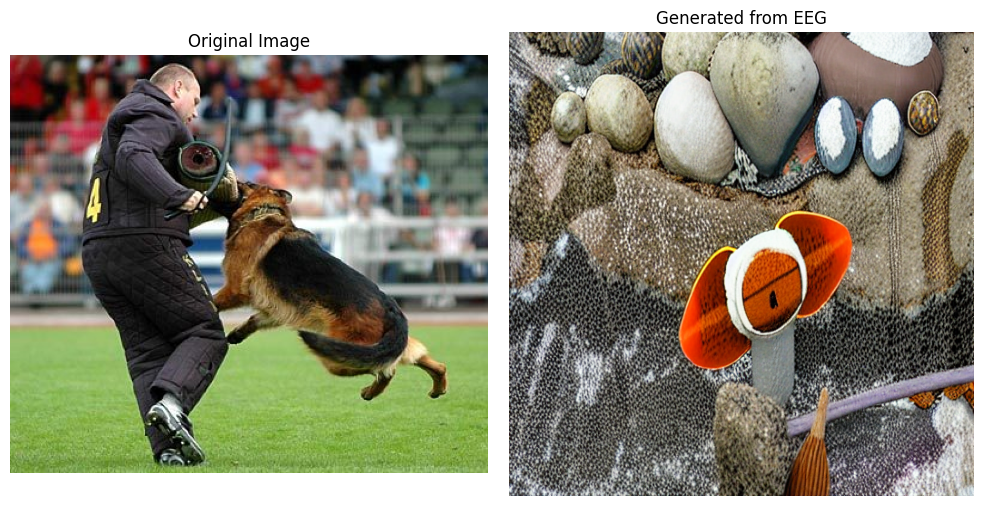

In [22]:
import torch
import numpy as np
from diffusers import AutoencoderKL, UNet2DConditionModel, DDIMScheduler
from diffusers.models.attention_processor import Attention, AttnProcessor
from torchvision.utils import save_image
import torchvision.transforms.functional as TF
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import torch.nn as nn

class EEGToCLIPText(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = torch.nn.Linear(512, 77 * 768)

    def forward(self, x):
        out = self.linear(x)
        return out.view(-1, 77, 768)

eeg_to_clip_text = EEGToCLIPText().cuda()
checkpoint = torch.load("/kaggle/input/datasets/vaibhavkalyan/dreamdiffusion-bcs/latest.pth", map_location="cuda")
eeg_to_clip_text.load_state_dict(checkpoint["model"])
eeg_to_clip_text.eval()
print("✅ Loaded eeg_to_clip_text from latest.pth")

device = "cuda" if torch.cuda.is_available() else "cpu"

class EEGCrossAttentionProcessor:
    def __init__(self):
        self.fallback = AttnProcessor()

    def __call__(self, attn_module, hidden_states, encoder_hidden_states=None, attention_mask=None, **kwargs):
        if encoder_hidden_states is None:
            return self.fallback(attn_module, hidden_states, encoder_hidden_states, attention_mask, **kwargs)

        query = attn_module.to_q(hidden_states)
        key = attn_module.to_k(encoder_hidden_states)
        value = attn_module.to_v(encoder_hidden_states)

        def reshape_heads(x):
            B, L, D = x.shape
            H = attn_module.heads
            D_head = D // H
            return x.view(B, L, H, D_head).transpose(1, 2)

        query = reshape_heads(query)
        key = reshape_heads(key)
        value = reshape_heads(value)

        scale = query.shape[-1] ** -0.5
        attn_scores = torch.matmul(query, key.transpose(-2, -1)) * scale

        if attention_mask is not None:
            attn_scores = attn_scores + attention_mask

        attn_probs = attn_scores.softmax(dim=-1)
        attn_output = torch.matmul(attn_probs, value)
        attn_output = attn_output.transpose(1, 2).reshape(hidden_states.shape)
        hidden_states = attn_module.to_out[0](attn_output)
        hidden_states = attn_module.to_out[1](hidden_states)
        return hidden_states

class EEGConditionedUNet(UNet2DConditionModel):
    def set_attention_processor(self):
        for name, module in self.named_modules():
            if isinstance(module, Attention):
                processor = EEGCrossAttentionProcessor()
                module.set_processor(processor)

vae = AutoencoderKL.from_pretrained("stable-diffusion-v1-5/stable-diffusion-v1-5", subfolder="vae").eval().to(device)
unet = EEGConditionedUNet.from_pretrained("stable-diffusion-v1-5/stable-diffusion-v1-5", subfolder="unet").to(device)
checkpoint = torch.load("/kaggle/input/datasets/vaibhavkalyan/dreamdiffusion-bcs/latest.pth", map_location=device)
unet.load_state_dict(checkpoint["unet"])
unet.eval()
print("✅ Loaded fine-tuned UNet from latest.pth")

unet.set_attn_processor(EEGCrossAttentionProcessor())

def generate_image_from_eeg(eeg_embed_avg):
    cond_embedding = eeg_to_clip_text(eeg_embed_avg.to(device))
    inference_scheduler = DDIMScheduler.from_pretrained("stable-diffusion-v1-5/stable-diffusion-v1-5", subfolder="scheduler")
    inference_scheduler.set_timesteps(100)

    uncond_embedding = torch.zeros_like(cond_embedding)
    cond_embedding = torch.cat([uncond_embedding, cond_embedding])

    latent = torch.randn(1, 4, 64, 64).to(device)

    for t in tqdm(inference_scheduler.timesteps, desc="Sampling"):
        latent_input = inference_scheduler.scale_model_input(latent, t)
        with torch.no_grad():
            noise_pred = unet(
                latent_input.expand(2, -1, -1, -1),
                t,
                encoder_hidden_states=cond_embedding
            ).sample
        noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)
        noise_pred = noise_pred_uncond + 7.5 * (noise_pred_text - noise_pred_uncond)
        latent = inference_scheduler.step(noise_pred, t, latent).prev_sample

    with torch.no_grad():
        image = vae.decode(latent / 0.18215).sample

    image = (image.clamp(-1, 1) + 1) / 2
    return image.cpu()

sample_idx = 1  # Change this (0 to ~11964) to try different EEG recordings

sample_eeg = projected_embeddings[sample_idx]
image_path = "/kaggle/input/datasets/vaibhavkalyan/dreamdiffusion-bcs/imageNet_images/imageNet_images/n02106662/n02106662_1560.JPEG"
orig_img_pil = Image.open(image_path).convert("RGB")

image_tensor = generate_image_from_eeg(sample_eeg)
gen_img_pil = TF.to_pil_image(image_tensor.squeeze())

save_image(image_tensor, "/kaggle/working/generated_image.png")

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(orig_img_pil)
axs[0].axis("off")
axs[0].set_title("Original Image")
axs[1].imshow(gen_img_pil)
axs[1].axis("off")
axs[1].set_title("Generated from EEG")
plt.tight_layout()
plt.show()